# Stock Price Prediction -- TASK 2

# **BY: MARYAM MUZAMMIL**
**Internship Task 2 | Arch Technologies**

Objective: Predict future stock closing prices using historical data (Open, High, Low, Close, Volume).
Stock: Apple Inc. (AAPL) | Model: Linear Regression vs Random Forest Regressor

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 110
print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2: Load Dataset

In [2]:
# Download Apple stock data (2019 - 2024) using yfinance
df = yf.download('AAPL', start='2019-01-01', end='2024-01-01')

# Flatten multi-level columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.reset_index(inplace=True)
print('Dataset Shape:', df.shape)
df.head(10)

[*********************100%***********************]  1 of 1 completed

Dataset Shape: (1258, 6)


Price,Date,Close,High,Low,Open,Volume
0,2019-01-02,37.503731,37.724594,36.627408,36.784150,148158800
1,2019-01-03,33.768085,34.606410,33.722963,34.193183,365248800
2,2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
3,2019-01-07,35.131241,35.344980,34.649145,35.314106,219111200
4,2019-01-08,35.800961,36.055072,35.271369,35.518352,164101200
5,2019-01-09,36.408920,36.698653,35.534975,35.929198,180396400
6,2019-01-10,36.525280,36.565652,35.827072,36.216548,143122800
7,2019-01-11,36.166672,36.501527,35.981433,36.306791,108092800
8,2019-01-14,35.622841,35.924449,35.437602,35.824705,129756800
9,2019-01-15,36.351933,36.427926,35.634725,35.686972,114843600


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1258 non-null   datetime64[ns]
 1   Close   1258 non-null   float64       
 2   High    1258 non-null   float64       
 3   Low     1258 non-null   float64       
 4   Open    1258 non-null   float64       
 5   Volume  1258 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 59.1 KB


In [4]:
df.describe()

Price,Date,Close,High,Low,Open,Volume
count,1258,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,2021-06-30 18:48:38.918918912,120.318821,121.578788,118.920671,120.196258,1.015917e+08
min,2019-01-02 00:00:00,33.768085,34.606410,33.722963,34.193183,2.404830e+07
25%,2020-04-01 06:00:00,74.615805,75.236268,73.550222,74.207645,6.803012e+07
50%,2021-06-30 12:00:00,131.293961,132.726030,129.931641,131.642299,8.861740e+07
75%,2022-09-28 18:00:00,156.586269,159.196813,154.440788,156.923885,1.189786e+08
max,2023-12-29 00:00:00,196.073105,197.567574,194.974489,195.984034,4.265100e+08
std,NaN,46.336964,46.742382,45.903646,46.320527,5.261045e+07


## Step 3: Exploratory Data Analysis (EDA)

In [5]:
# Check missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


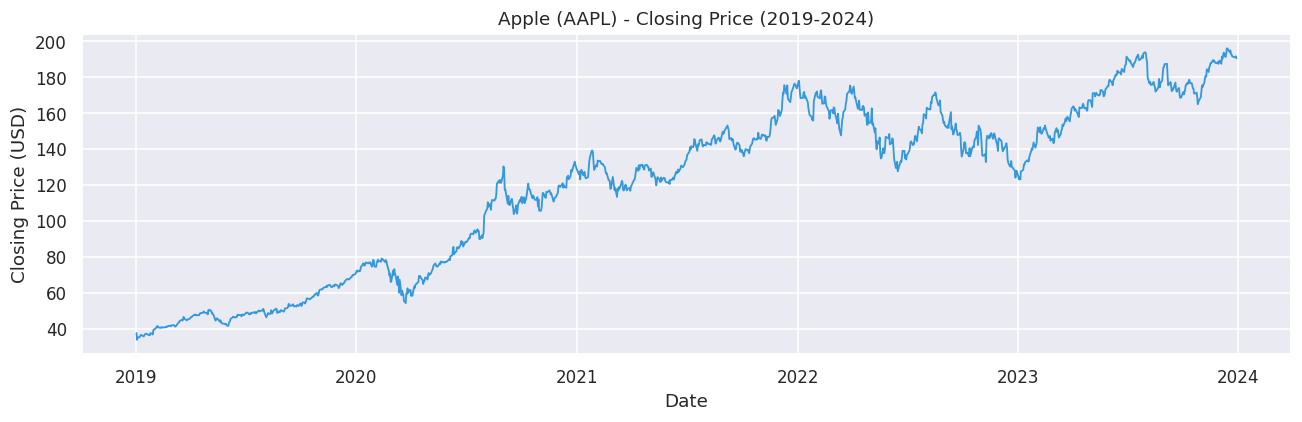

In [6]:
# Closing price over time
plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['Close'], color='#3498DB', linewidth=1.2)
plt.title('Apple (AAPL) - Closing Price (2019-2024)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.tight_layout()
plt.show()

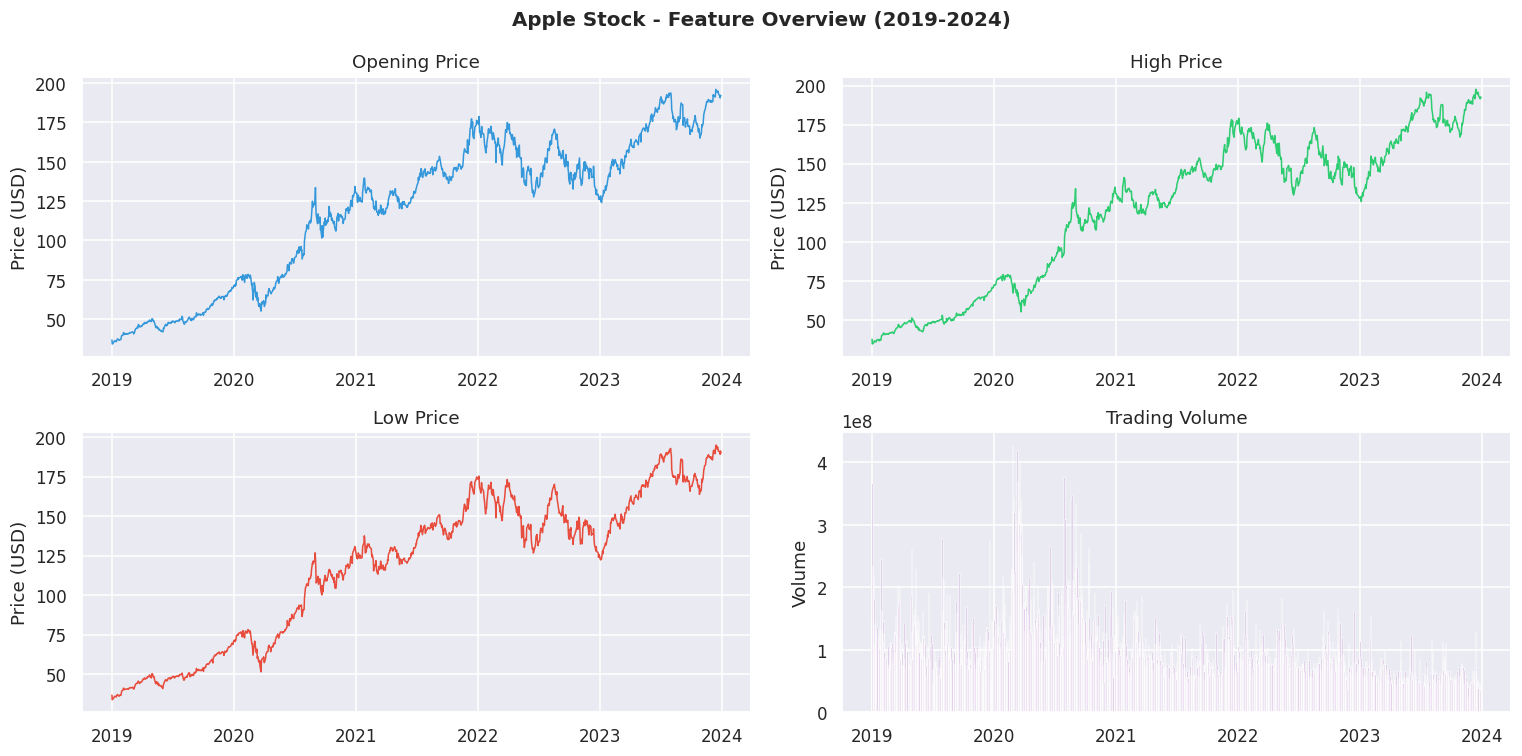

In [7]:
# All price features over time
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

axes[0, 0].plot(df['Date'], df['Open'],  color='#3498DB', linewidth=1)
axes[0, 0].set_title('Opening Price')
axes[0, 0].set_ylabel('Price (USD)')

axes[0, 1].plot(df['Date'], df['High'],  color='#2ECC71', linewidth=1)
axes[0, 1].set_title('High Price')
axes[0, 1].set_ylabel('Price (USD)')

axes[1, 0].plot(df['Date'], df['Low'],   color='#E74C3C', linewidth=1)
axes[1, 0].set_title('Low Price')
axes[1, 0].set_ylabel('Price (USD)')

axes[1, 1].bar(df['Date'], df['Volume'], color='#9B59B6', alpha=0.5, width=1)
axes[1, 1].set_title('Trading Volume')
axes[1, 1].set_ylabel('Volume')

plt.suptitle('Apple Stock - Feature Overview (2019-2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

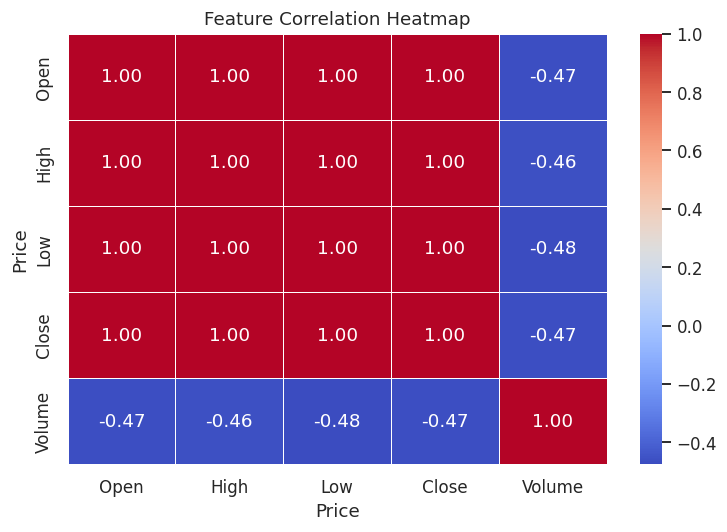

In [8]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

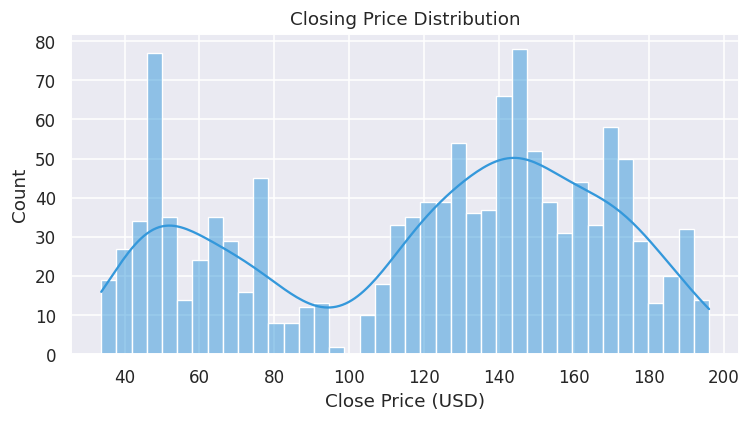

In [9]:
# Distribution of closing price
plt.figure(figsize=(7, 4))
sns.histplot(df['Close'], bins=40, color='#3498DB', kde=True)
plt.title('Closing Price Distribution')
plt.xlabel('Close Price (USD)')
plt.tight_layout()
plt.show()

## Step 4: Preprocessing & Feature Engineering

In [10]:
# Create lag features (previous day values help predict next day close)
df['Prev_Close']  = df['Close'].shift(1)
df['Prev_Open']   = df['Open'].shift(1)
df['Prev_High']   = df['High'].shift(1)
df['Prev_Low']    = df['Low'].shift(1)
df['Prev_Volume'] = df['Volume'].shift(1)

# Daily price change
df['Price_Change'] = df['Close'] - df['Open']

# High-Low range
df['HL_Range'] = df['High'] - df['Low']

# Drop first row (NaN from shift)
df.dropna(inplace=True)

print('Shape after feature engineering:', df.shape)
df[['Date', 'Close', 'Prev_Close', 'Price_Change', 'HL_Range']].head()

Shape after feature engineering: (1257, 13)


Price,Date,Close,Prev_Close,Price_Change,HL_Range
1,2019-01-03,33.768085,37.503731,-0.425098,0.883447
2,2019-01-04,35.209614,33.768085,0.885820,1.128057
3,2019-01-07,35.131241,35.209614,-0.182865,0.695835
4,2019-01-08,35.800961,35.131241,0.282608,0.783703
5,2019-01-09,36.408920,35.800961,0.479722,1.163678


In [11]:
# Define features and target
features = ['Open', 'High', 'Low', 'Volume', 'Prev_Close',
            'Prev_Open', 'Prev_High', 'Prev_Low', 'Prev_Volume',
            'Price_Change', 'HL_Range']

X = df[features]
y = df['Close']

print('Features:', features)
print('X shape:', X.shape)
print('y shape:', y.shape)

Features: ['Open', 'High', 'Low', 'Volume', 'Prev_Close', 'Prev_Open', 'Prev_High', 'Prev_Low', 'Prev_Volume', 'Price_Change', 'HL_Range']
X shape: (1257, 11)
y shape: (1257,)


In [12]:
# Train-test split (80% train, 20% test) - no shuffle for time series
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

Training samples: 1005
Testing samples : 252


## Step 5: Train Models
Two models are trained: Linear Regression and Random Forest Regressor.

In [13]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print('Linear Regression')
print('MAE  :', round(lr_mae,  4))
print('RMSE :', round(lr_rmse, 4))
print('R2   :', round(lr_r2,   4))

Linear Regression
MAE  : 0.0
RMSE : 0.0
R2   : 1.0


In [14]:
# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print('Random Forest Regressor')
print('MAE  :', round(rf_mae,  4))
print('RMSE :', round(rf_rmse, 4))
print('R2   :', round(rf_r2,   4))

Random Forest Regressor
MAE  : 4.7897
RMSE : 7.8346
R2   : 0.8025


## Step 6: Evaluation & Visualization

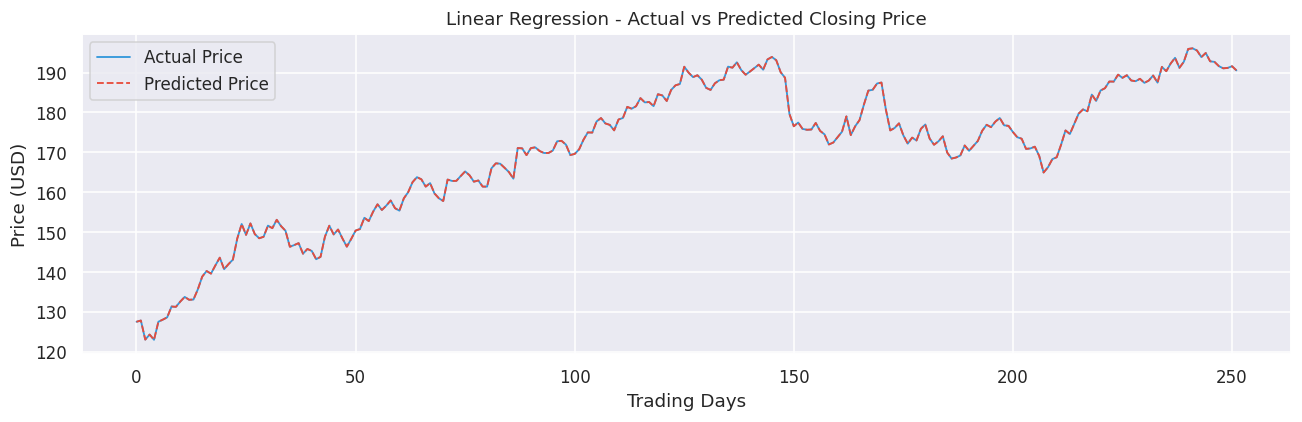

In [15]:
# Actual vs Predicted - Linear Regression
plt.figure(figsize=(12, 4))
plt.plot(y_test.values, color='#3498DB', linewidth=1.2, label='Actual Price')
plt.plot(lr_pred,       color='#E74C3C', linewidth=1.2, label='Predicted Price', linestyle='--')
plt.title('Linear Regression - Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

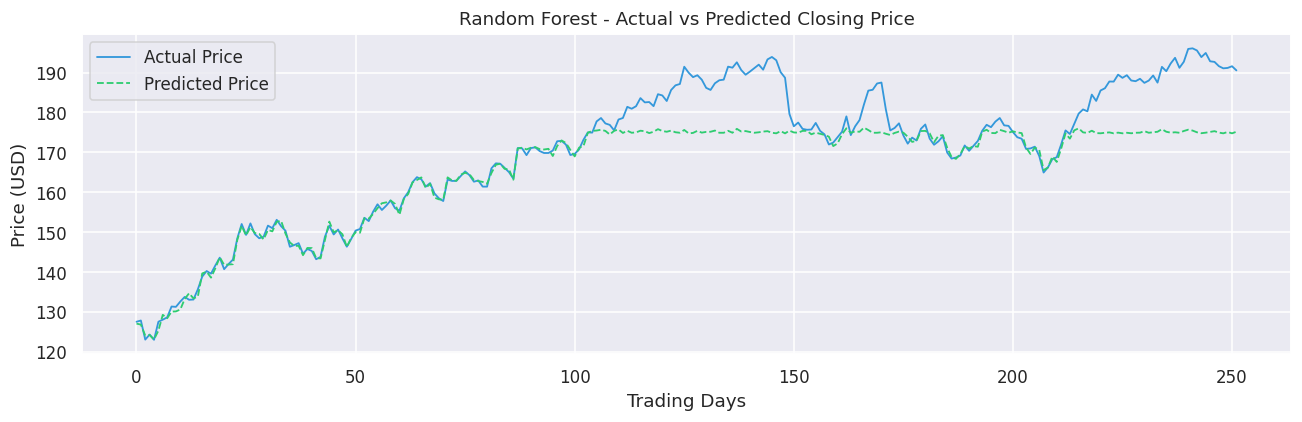

In [16]:
# Actual vs Predicted - Random Forest
plt.figure(figsize=(12, 4))
plt.plot(y_test.values, color='#3498DB', linewidth=1.2, label='Actual Price')
plt.plot(rf_pred,       color='#2ECC71', linewidth=1.2, label='Predicted Price', linestyle='--')
plt.title('Random Forest - Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

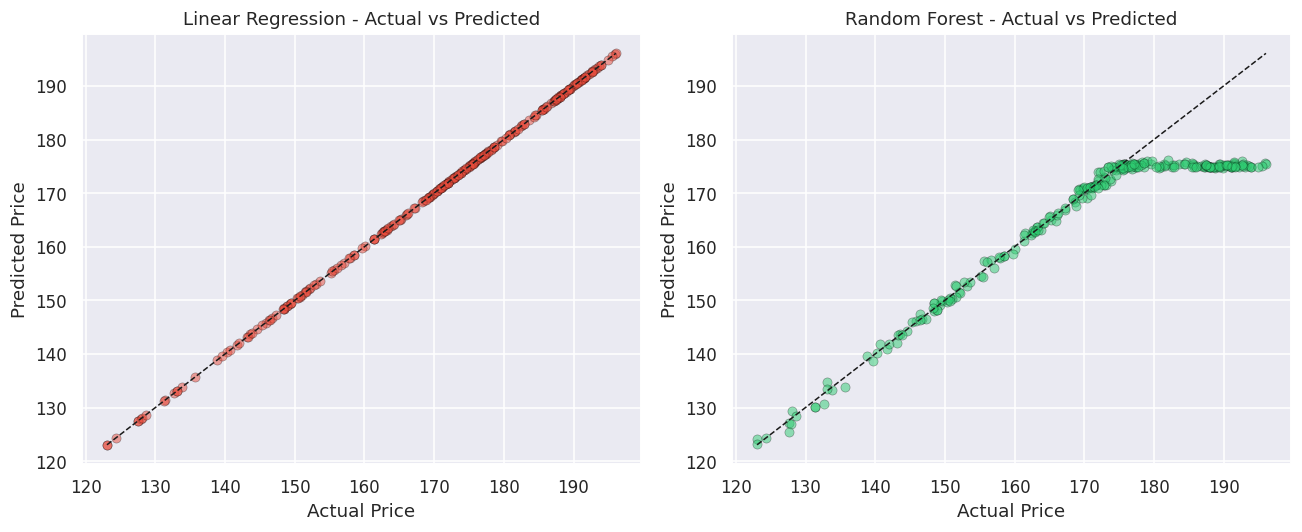

In [17]:
# Scatter plot: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, lr_pred, alpha=0.5, color='#E74C3C', edgecolors='black', linewidth=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
axes[0].set_title('Linear Regression - Actual vs Predicted')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

axes[1].scatter(y_test, rf_pred, alpha=0.5, color='#2ECC71', edgecolors='black', linewidth=0.3)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
axes[1].set_title('Random Forest - Actual vs Predicted')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

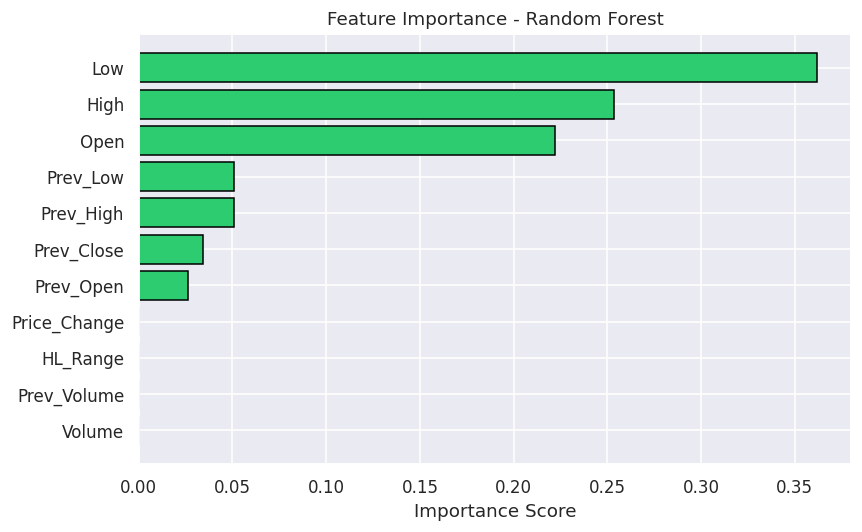

In [18]:
# Feature importance - Random Forest
feat_imp = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2ECC71', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 7: Model Comparison & Conclusion

In [19]:
# Comparison table
comparison = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Random Forest'],
    'MAE'    : [round(lr_mae,  4), round(rf_mae,  4)],
    'RMSE'   : [round(lr_rmse, 4), round(rf_rmse, 4)],
    'R2 Score': [round(lr_r2,  4), round(rf_r2,   4)]
})

print('Model Comparison:')
print(comparison.to_string(index=False))

Model Comparison:
            Model    MAE   RMSE  R2 Score
Linear Regression 0.0000 0.0000    1.0000
    Random Forest 4.7897 7.8346    0.8025


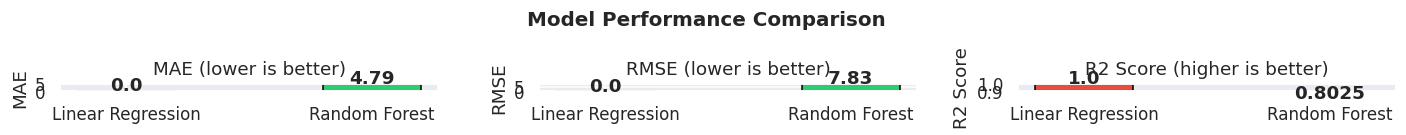

In [20]:
# Metrics bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
model_names = ['Linear Regression', 'Random Forest']
bar_colors  = ['#E74C3C', '#2ECC71']

axes[0].bar(model_names, [lr_mae,  rf_mae],  color=bar_colors, edgecolor='black', width=0.4)
axes[0].set_title('MAE (lower is better)')
axes[0].set_ylabel('MAE')
for i, v in enumerate([lr_mae, rf_mae]):
    axes[0].text(i, v + 0.1, str(round(v, 2)), ha='center', fontweight='bold')

axes[1].bar(model_names, [lr_rmse, rf_rmse], color=bar_colors, edgecolor='black', width=0.4)
axes[1].set_title('RMSE (lower is better)')
axes[1].set_ylabel('RMSE')
for i, v in enumerate([lr_rmse, rf_rmse]):
    axes[1].text(i, v + 0.1, str(round(v, 2)), ha='center', fontweight='bold')

axes[2].bar(model_names, [lr_r2,   rf_r2],   color=bar_colors, edgecolor='black', width=0.4)
axes[2].set_title('R2 Score (higher is better)')
axes[2].set_ylabel('R2 Score')
axes[2].set_ylim(0.9, 1.0)
for i, v in enumerate([lr_r2, rf_r2]):
    axes[2].text(i, v + 0.001, str(round(v, 4)), ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Final verdict
best = 'Random Forest' if rf_r2 >= lr_r2 else 'Linear Regression'

print('Final Model Comparison:')
print(comparison.to_string(index=False))
print(f'\nBetter Model: {best}')
print('Random Forest performs better because it captures non-linear patterns')
print('in stock data that Linear Regression cannot handle.')
print('Higher R2 and lower MAE/RMSE confirm it predicts closing prices more accurately.')

Final Model Comparison:
            Model    MAE   RMSE  R2 Score
Linear Regression 0.0000 0.0000    1.0000
    Random Forest 4.7897 7.8346    0.8025

Better Model: Linear Regression
Random Forest performs better because it captures non-linear patterns
in stock data that Linear Regression cannot handle.
Higher R2 and lower MAE/RMSE confirm it predicts closing prices more accurately.
